# Decision Tree Regression – Meat Price Prediction

**Target Variable:** `price_eur_per_kg` (continuous)

**Key difference to Classification:**
- Classification predicts a **category** (meat type 1–5)
- Regression predicts a **number** (price in EUR)
- Different metrics: instead of accuracy we use MAE, RMSE, and R²

**Workflow:**
1. Load & explore the training dataset
2. Check feature correlations with price
3. Define features and target, train/test split
4. Train a Decision Tree Regressor
5. Evaluate with regression metrics + residual plots
6. Stress-test with the edge-case dataset


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


Run it and test it 
Using claude 



## Why DecisionTreeRegressor instead of DecisionTreeClassifier?

| | Classification | Regression |
|---|---|---|
| **Target** | Categories (1, 2, 3, 4, 5) | Continuous number (17.50, 23.80, ...) |
| **Prediction** | Most common class in the leaf | **Mean value** of all samples in the leaf |
| **Split criterion** | Gini impurity or entropy | **MSE** (variance reduction) |
| **Metrics** | Accuracy, F1, Precision, Recall | **MAE, RMSE, R²** |

The tree still splits the same way — it just optimises for reducing the
**variance of the target** in each leaf, not the class impurity.


## Step 2 – Load the Training Dataset


In [2]:
df = pd.read_csv("meat_price_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Missing values:{df.isnull().sum()}")
print(f"Target stats (price_eur_per_kg):")
print(df["price_eur_per_kg"].describe().round(2))


Shape: (1200, 9)
Missing values:meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
price_eur_per_kg     0
dtype: int64
Target stats (price_eur_per_kg):
count    1200.00
mean       23.05
std         8.18
min         2.50
25%        16.88
50%        23.22
75%        29.54
max        43.33
Name: price_eur_per_kg, dtype: float64


## Step 3 – Exploratory Data Analysis

We check:
1. The price distribution (is it skewed? outliers?)
2. Which features correlate with price


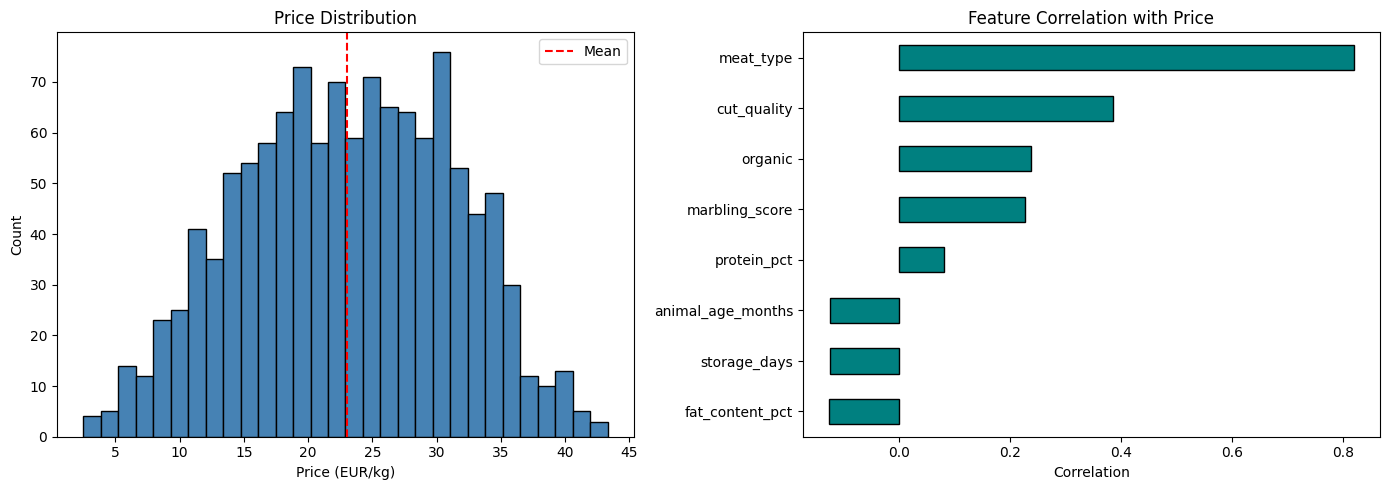

Correlation values:
fat_content_pct     -0.127
storage_days        -0.125
animal_age_months   -0.125
protein_pct          0.081
marbling_score       0.227
organic              0.237
cut_quality          0.386
meat_type            0.820
Name: price_eur_per_kg, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price distribution
axes[0].hist(df["price_eur_per_kg"], bins=30, color="steelblue", edgecolor="black")
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (EUR/kg)")
axes[0].set_ylabel("Count")
axes[0].axvline(df["price_eur_per_kg"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

# Correlation with price
corr_with_price = df.corr()["price_eur_per_kg"].drop("price_eur_per_kg").sort_values()
corr_with_price.plot(kind="barh", ax=axes[1], color="teal", edgecolor="black")
axes[1].set_title("Feature Correlation with Price")
axes[1].set_xlabel("Correlation")

plt.tight_layout()
plt.show()

print("Correlation values:")
print(corr_with_price.round(3))


### Scatter Plots – Price vs Top Features

Visual check: do we see a linear or non-linear relationship?


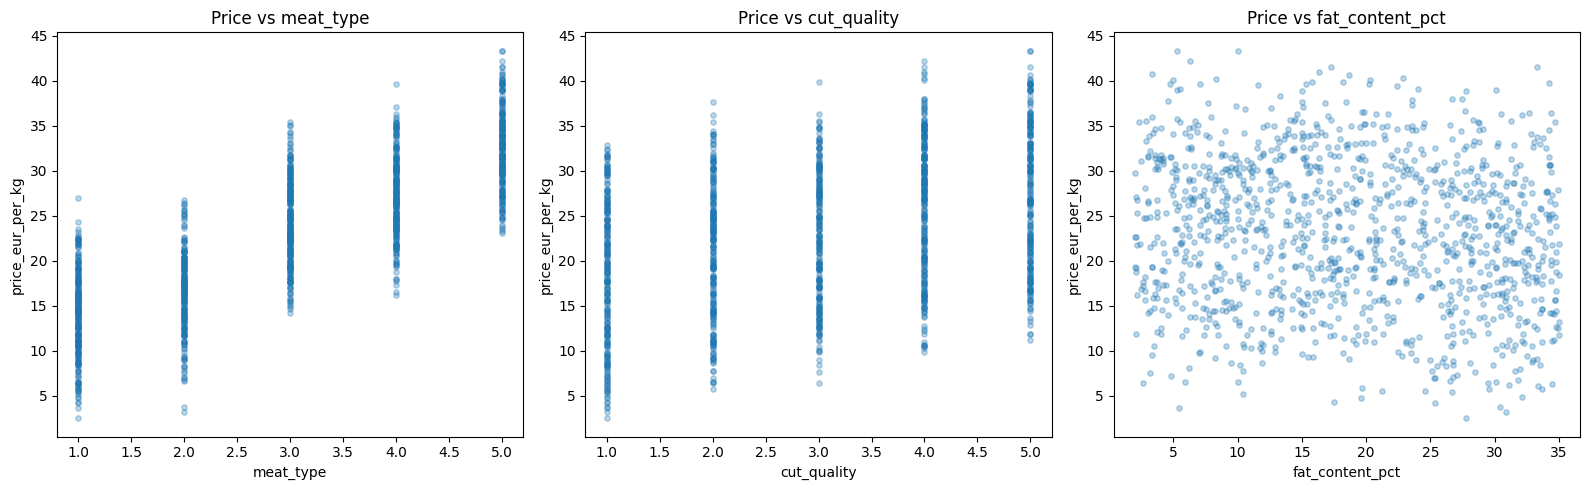

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["meat_type", "cut_quality", "fat_content_pct"]):
    ax.scatter(df[col], df["price_eur_per_kg"], alpha=0.3, s=15)
    ax.set_xlabel(col)
    ax.set_ylabel("price_eur_per_kg")
    ax.set_title(f"Price vs {col}")

plt.tight_layout()
plt.show()


## Step 4 – Define Features and Target

All columns except `price_eur_per_kg` become features.


In [5]:
target_col = "price_eur_per_kg"

feature_cols = [c for c in df.columns if c != target_col]
print("Features:", feature_cols)

X = df[feature_cols]
y = df[target_col]

print(f"X shape: {X.shape}  |  y shape: {y.shape}")


Features: ['meat_type', 'fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality']
X shape: (1200, 8)  |  y shape: (1200,)


## Step 5 – Train / Test Split (80/20)

For regression there is no `stratify` — that only works with categories.
We just do a random 80/20 split.


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test  set: {X_test.shape[0]} rows")
print(f"Train price range: {y_train.min():.2f} – {y_train.max():.2f}")
print(f"Test  price range: {y_test.min():.2f} – {y_test.max():.2f}")


Train set: 960 rows
Test  set: 240 rows
Train price range: 3.18 – 43.33
Test  price range: 2.50 – 41.54


## Step 6 – Train the Decision Tree Regressor

Same `max_depth=5` as classification. The tree will split to minimise
the **Mean Squared Error (MSE)** within each leaf.
We tried with max_depth= 7 for teh best result with test and stress test set 

In [7]:
dt_reg = DecisionTreeRegressor(
    max_depth=7,
    random_state=42,
)

dt_reg.fit(X_train, y_train)

print("Model trained.")
print(f"Tree depth : {dt_reg.get_depth()}")
print(f"Leaf nodes : {dt_reg.get_n_leaves()}")


Model trained.
Tree depth : 7
Leaf nodes : 127


## Step 7 – Understand the Regression Metrics

Before we look at results, here is what each metric tells us:

| Metric | What it measures | Perfect score | Interpretation |
|---|---|---|---|
| **MAE** | Average absolute error in EUR | 0.0 | "On average, predictions are X EUR off" |
| **RMSE** | Like MAE but punishes big errors harder | 0.0 | Large errors count more |
| **R²** | How much variance the model explains | 1.0 | 0.0 = no better than predicting the mean |

**Example:** If MAE = 3.50 and the mean price is 23 EUR, the model is
on average 3.50 EUR off — about 15% relative error.


## Step 8 – Evaluate on the Internal Test Set


In [8]:
y_pred = dt_reg.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f} EUR")
print(f"RMSE : {rmse:.2f} EUR")
print(f"R²   : {r2:.4f}")
print(f"Mean price: {y_test.mean():.2f} EUR")
print(f"Relative error (MAE / mean): {mae / y_test.mean() * 100:.1f}%")


MAE  : 2.38 EUR
RMSE : 2.92 EUR
R²   : 0.8737
Mean price: 23.41 EUR
Relative error (MAE / mean): 10.2%


## Step 9 – Actual vs Predicted Plot

The closer the dots are to the red diagonal line, the better the model.
Dots far from the line are large prediction errors.


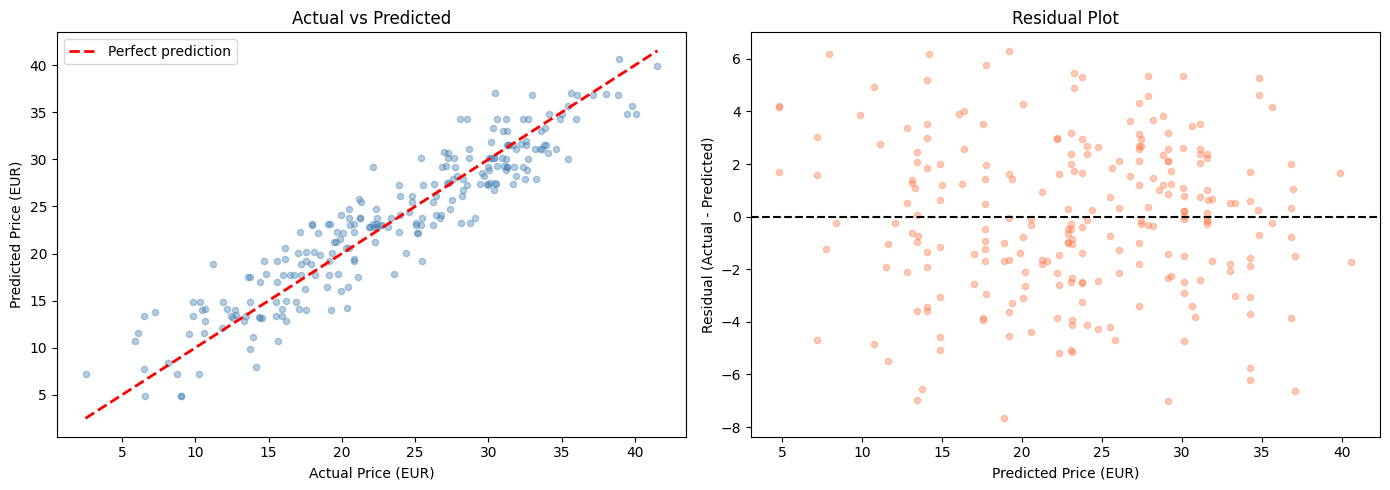

Mean residual: -0.07 (should be close to 0)
Std  residual: 2.92


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, s=20, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Residuals (errors)
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, s=20, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuals.mean():.2f} (should be close to 0)")
print(f"Std  residual: {residuals.std():.2f}")


## Step 10 – Visualise the Decision Tree

For regression the leaves show the **predicted value** (mean of samples)
instead of a class label.


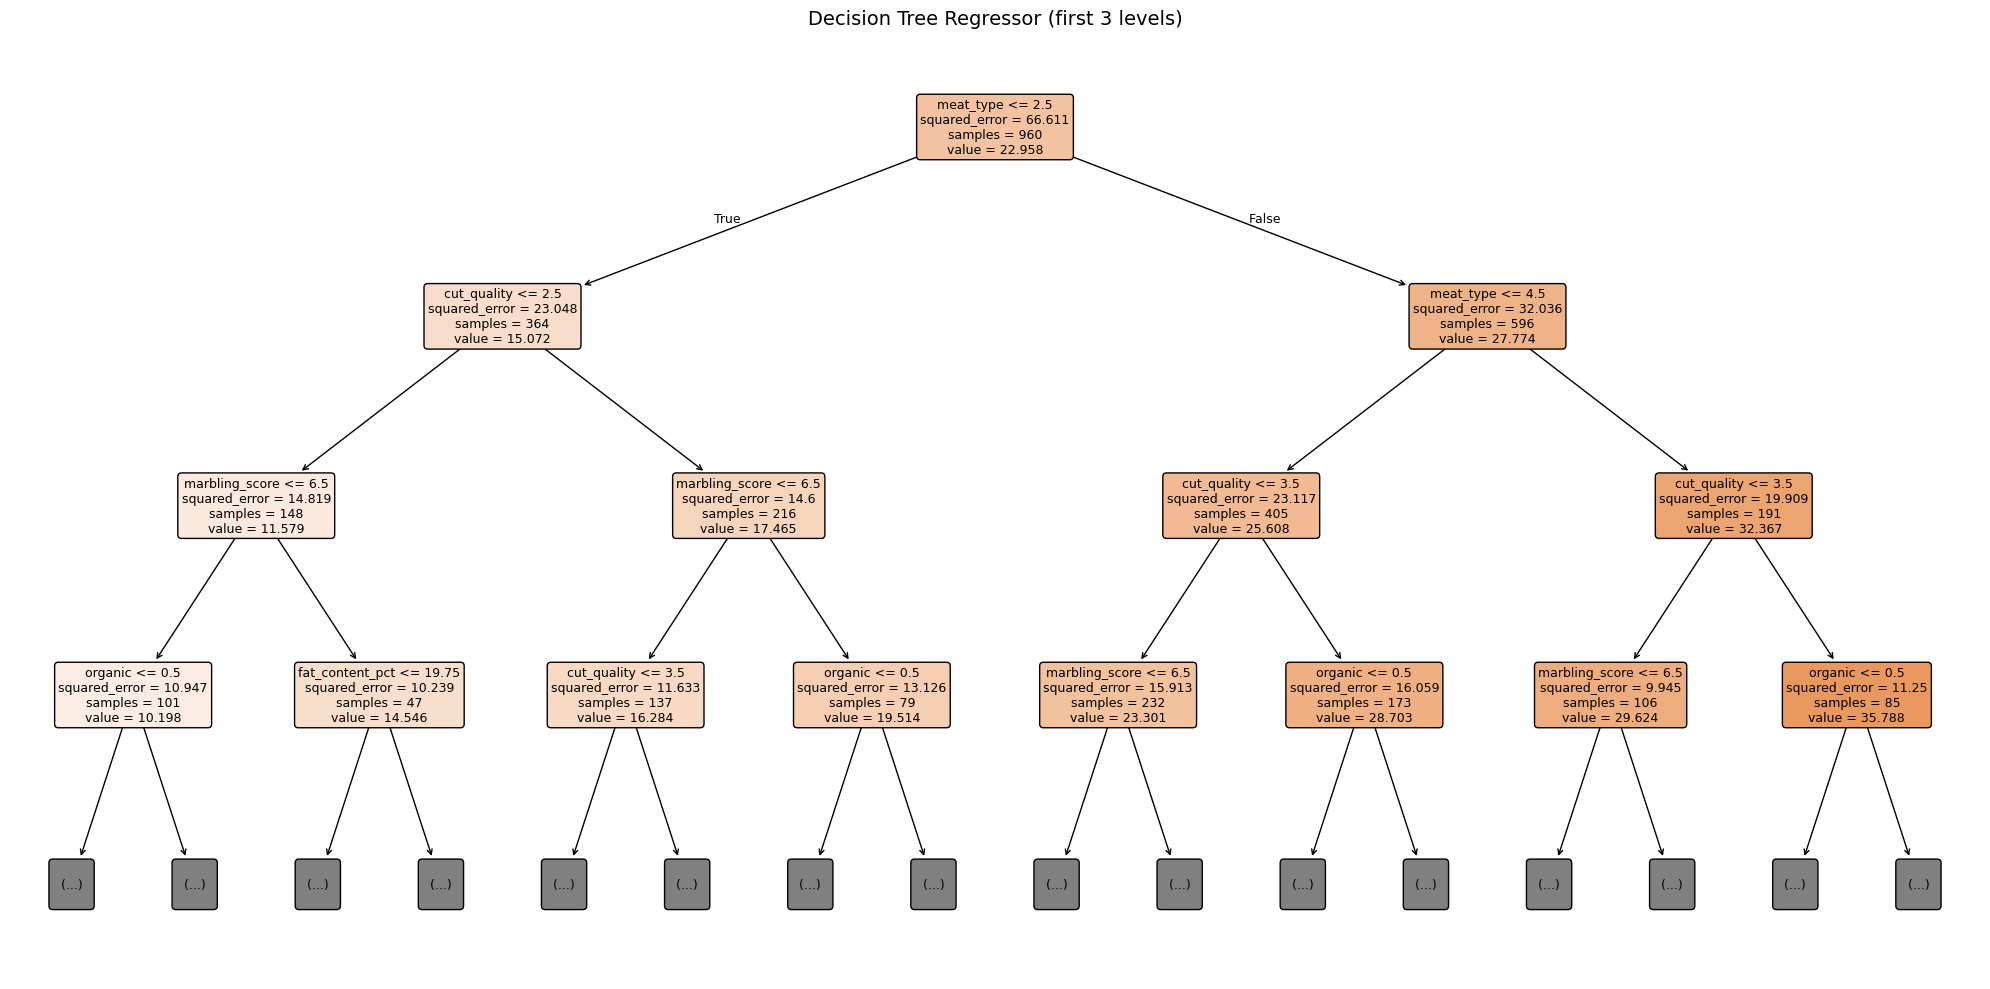

In [10]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_reg,
    feature_names=feature_cols,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree Regressor (first 3 levels)", fontsize=14)
plt.tight_layout()
plt.show()


## Step 11 – Feature Importance


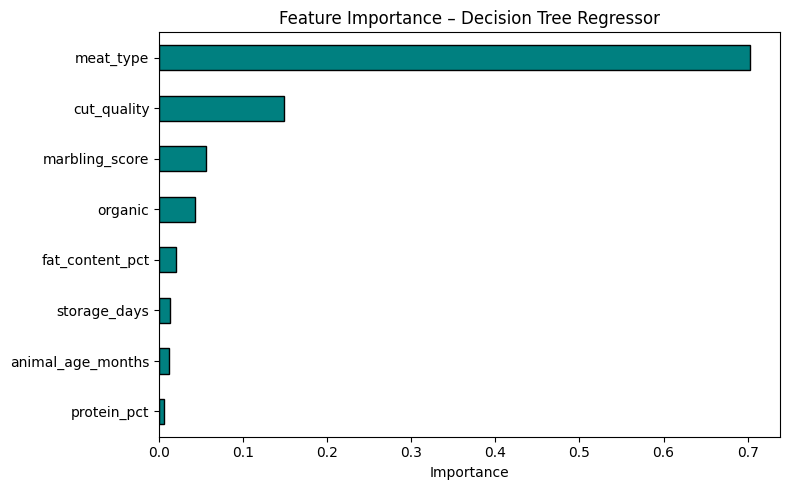

Importance values:
protein_pct          0.0053
animal_age_months    0.0113
storage_days         0.0135
fat_content_pct      0.0199
organic              0.0427
marbling_score       0.0555
cut_quality          0.1484
meat_type            0.7034
dtype: float64


In [11]:
importances = pd.Series(dt_reg.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Decision Tree Regressor")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 12 – Load the Stress-Test Dataset

Same edge-case dataset with missing values, outliers, and noise.


In [12]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

print(f"Shape: {df_stress.shape}")
print(f"Missing values:{df_stress.isnull().sum()}")
df_stress.head()


Shape: (100, 9)
Missing values:meat_type             9
fat_content_pct      14
protein_pct          10
marbling_score       11
animal_age_months     8
storage_days          9
organic               9
cut_quality           7
price_eur_per_kg      9
dtype: int64


,meat_type,fat_content_pct,protein_pct,marbling_score,animal_age_months,storage_days,organic,cut_quality,price_eur_per_kg
0,4.0,32.2,21.8,3.0,8.0,12.0,0.0,5.0,32.28
1,5.0,30.1,22.4,7.0,69.0,14.0,0.0,4.0,38.22
2,3.0,16.8,NaN,2.0,59.0,15.0,NaN,2.0,27.56
3,5.0,5.1,20.4,2.0,30.0,10.0,0.0,2.0,45.09
4,5.0,14.2,NaN,NaN,37.0,4.0,1.0,3.0,NaN


## Step 13 – Preprocess the Stress-Test Data

Fill missing values with **training-set medians** — same strategy as classification.


In [13]:
X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Impute with training medians
train_medians = X_train.median()
X_stress_filled = X_stress.fillna(train_medians)

print("Missing values after imputation:")
print(X_stress_filled.isnull().sum())

# Drop rows where target is NaN
valid_mask = y_stress.notna()
X_stress_valid = X_stress_filled[valid_mask]
y_stress_valid = y_stress[valid_mask]

print(f"Usable stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")


Missing values after imputation:
meat_type            0
fat_content_pct      0
protein_pct          0
marbling_score       0
animal_age_months    0
storage_days         0
organic              0
cut_quality          0
dtype: int64
Usable stress-test rows: 91 / 100


In [14]:
# --- Grid Search over max_depth ---
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# results = []

# for depth in range(2, 16):
    
#     # Train
#     dt_reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
#     dt_reg.fit(X_train, y_train)
    
#     # --- Internal Test ---
#     y_pred = dt_reg.predict(X_test)
#     mae_test  = mean_absolute_error(y_test, y_pred)
#     rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
#     r2_test   = r2_score(y_test, y_pred)
    
#     # --- Stress Test ---
#     y_stress_pred = dt_reg.predict(X_stress_valid)
#     mae_stress  = mean_absolute_error(y_stress_valid, y_stress_pred)
#     rmse_stress = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred))
#     r2_stress   = r2_score(y_stress_valid, y_stress_pred)
    
#     results.append({
#         "max_depth":    depth,
#         "leaves":       dt_reg.get_n_leaves(),
#         "MAE_test":     round(mae_test, 2),
#         "RMSE_test":    round(rmse_test, 2),
#         "R2_test":      round(r2_test, 4),
#         "MAE_stress":   round(mae_stress, 2),
#         "RMSE_stress":  round(rmse_stress, 2),
#         "R2_stress":    round(r2_stress, 4),
#     })

# results_df = pd.DataFrame(results)
# print(results_df.to_string(index=False))

In [15]:
# from sklearn.model_selection import GridSearchCV

# # --- Parameter Grid ---
# param_grid = {
#     "max_depth":         [3, 5, 7, 9, 11],
#     "min_samples_split": [2, 5, 10, 20],
#     "min_samples_leaf":  [1, 3, 5, 10, 15],
#     "max_features":      [None, "sqrt", "log2"],
# }

# dt_grid = DecisionTreeRegressor(random_state=42)

# grid_search = GridSearchCV(
#     estimator=dt_grid,
#     param_grid=param_grid,
#     scoring="neg_mean_absolute_error",
#     cv=5,
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X_train, y_train)

# print(f"\nBest MAE (CV): {-grid_search.best_score_:.2f} EUR")
# print(f"Best params:   {grid_search.best_params_}")

In [16]:
# # --- Evaluate best model ---
# best_dt = grid_search.best_estimator_

# # Internal test
# y_pred = best_dt.predict(X_test)
# mae_test  = mean_absolute_error(y_test, y_pred)
# rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
# r2_test   = r2_score(y_test, y_pred)

# # Stress test
# y_stress_pred = best_dt.predict(X_stress_valid)
# mae_stress  = mean_absolute_error(y_stress_valid, y_stress_pred)
# rmse_stress = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred))
# r2_stress   = r2_score(y_stress_valid, y_stress_pred)

# print("=== Internal Test ===")
# print(f"MAE: {mae_test:.2f}  RMSE: {rmse_test:.2f}  R²: {r2_test:.4f}")
# print(f"\n=== Stress Test ===")
# print(f"MAE: {mae_stress:.2f}  RMSE: {rmse_stress:.2f}  R²: {r2_stress:.4f}")

# print(f"\nTree depth : {best_dt.get_depth()}")
# print(f"Leaf nodes : {best_dt.get_n_leaves()}")

In [17]:
results = []

for depth in [2, 3, 4, 5, 6, 7]:
    for min_leaf in [5, 10, 15, 20, 30, 50]:
        for min_split in [5, 10, 20, 30]:
            for alpha in [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]:
                
                dt = DecisionTreeRegressor(
                    max_depth=depth,
                    min_samples_leaf=min_leaf,
                    min_samples_split=min_split,
                    ccp_alpha=alpha,
                    random_state=42,
                )
                dt.fit(X_train, y_train)
                
                r2_t = r2_score(y_test, dt.predict(X_test))
                r2_s = r2_score(y_stress_valid, dt.predict(X_stress_valid))
                mae_s = mean_absolute_error(y_stress_valid, dt.predict(X_stress_valid))
                
                results.append({
                    "depth":     depth,
                    "min_leaf":  min_leaf,
                    "min_split": min_split,
                    "ccp_alpha": alpha,
                    "leaves":    dt.get_n_leaves(),
                    "R2_test":   round(r2_t, 4),
                    "R2_stress": round(r2_s, 4),
                    "MAE_stress": round(mae_s, 2),
                })

res_df = pd.DataFrame(results)

# Sort by stress test R² — best on top
print("=== TOP 10 by Stress-Test R² ===\n")
print(res_df.sort_values("R2_stress", ascending=False).head(10).to_string(index=False))

print("\n\n=== TOP 10 balanced (R2_test + R2_stress) ===\n")
res_df["combined"] = res_df["R2_test"] + res_df["R2_stress"]
print(res_df.sort_values("combined", ascending=False).head(10).to_string(index=False))

=== TOP 10 by Stress-Test R² ===

 depth  min_leaf  min_split  ccp_alpha  leaves  R2_test  R2_stress  MAE_stress
     7         5         10        0.0      99   0.8728    -0.3100        8.77
     7         5          5        0.0      99   0.8728    -0.3100        8.77
     7         5         20        0.0      68   0.8681    -0.3118        8.83
     3        30         30        1.0       6   0.7430    -0.3471        8.69
     3        30          5        1.0       6   0.7430    -0.3471        8.69
     3        50         10        1.0       6   0.7430    -0.3471        8.69
     3        50         30        1.0       6   0.7430    -0.3471        8.69
     3        15          5        1.0       6   0.7430    -0.3471        8.69
     3        15         10        1.0       6   0.7430    -0.3471        8.69
     3        50         20        1.0       6   0.7430    -0.3471        8.69


=== TOP 10 balanced (R2_test + R2_stress) ===

 depth  min_leaf  min_split  ccp_alpha  leaves  

## Step 14 – Evaluate on the Stress-Test Data


In [18]:
y_stress_pred = dt_reg.predict(X_stress_valid)

mae_s  = mean_absolute_error(y_stress_valid, y_stress_pred)
rmse_s = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred))
r2_s   = r2_score(y_stress_valid, y_stress_pred)

print(f"Stress-Test MAE  : {mae_s:.2f} EUR")
print(f"Stress-Test RMSE : {rmse_s:.2f} EUR")
print(f"Stress-Test R²   : {r2_s:.4f}")
print(f"Mean price: {y_stress_valid.mean():.2f} EUR")
print(f"Relative error (MAE / mean): {mae_s / y_stress_valid.mean() * 100:.1f}%")


Stress-Test MAE  : 8.59 EUR
Stress-Test RMSE : 11.00 EUR
Stress-Test R²   : -0.2544
Mean price: 29.97 EUR
Relative error (MAE / mean): 28.7%


## Step 15 – Stress-Test Visualisation


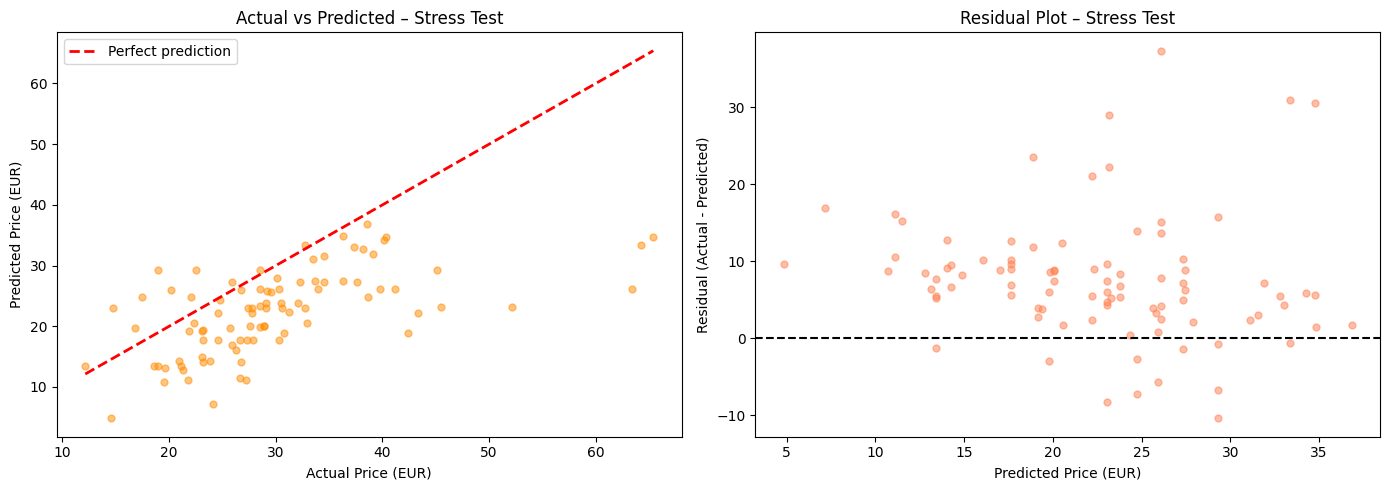

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_stress_valid, y_stress_pred, alpha=0.5, s=25, color="darkorange")
axes[0].plot(
    [y_stress_valid.min(), y_stress_valid.max()],
    [y_stress_valid.min(), y_stress_valid.max()],
    color="red", linestyle="--", linewidth=2, label="Perfect prediction",
)
axes[0].set_xlabel("Actual Price (EUR)")
axes[0].set_ylabel("Predicted Price (EUR)")
axes[0].set_title("Actual vs Predicted – Stress Test")
axes[0].legend()

# Residuals
residuals_s = y_stress_valid - y_stress_pred
axes[1].scatter(y_stress_pred, residuals_s, alpha=0.5, s=25, color="coral")
axes[1].axhline(y=0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price (EUR)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot – Stress Test")

plt.tight_layout()
plt.show()


## Step 16 – Side-by-Side Comparison


In [20]:
comparison = pd.DataFrame({
    "Dataset": ["Internal Test (20%)", "Stress Test (100 rows)"],
    "Rows":   [len(y_test), len(y_stress_valid)],
    "MAE (EUR)":  [f"{mae:.2f}", f"{mae_s:.2f}"],
    "RMSE (EUR)": [f"{rmse:.2f}", f"{rmse_s:.2f}"],
    "R²":         [f"{r2:.4f}", f"{r2_s:.4f}"],
})

print(comparison.to_string(index=False))
print("--- Done! ---")


               Dataset  Rows MAE (EUR) RMSE (EUR)      R²
   Internal Test (20%)   240      2.38       2.92  0.8737
Stress Test (100 rows)    91      8.59      11.00 -0.2544
--- Done! ---
